In [1]:
%cd ..

/Users/kiwifern/Development/airfoil-completion


/Users/kiwifern/Development/airfoil-completion/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
from xfoil import XFoil

In [3]:
xf = XFoil()

In [2]:
import numpy as np
import torch

In [6]:
c_mask = torch.Tensor([[33,33,33],[44,44,44]])
c_mask

tensor([[33., 33., 33.],
        [44., 44., 44.]])

In [ ]:
uncond_mask = torch.zeros(c_mask.size(0), dtype=torch.bool)
uncond_mask

tensor([False, False])

In [16]:
p_uncond = 0.5
mask = torch.rand(c_mask.size(0)) < p_uncond
mask

tensor([ True, False])

In [18]:
c_mask * uncond_mask.unsqueeze(1)

tensor([[0., 0., 0.],
        [0., 0., 0.]])

In [19]:
c_mask * mask.unsqueeze(1)

tensor([[33., 33., 33.],
        [ 0.,  0.,  0.]])

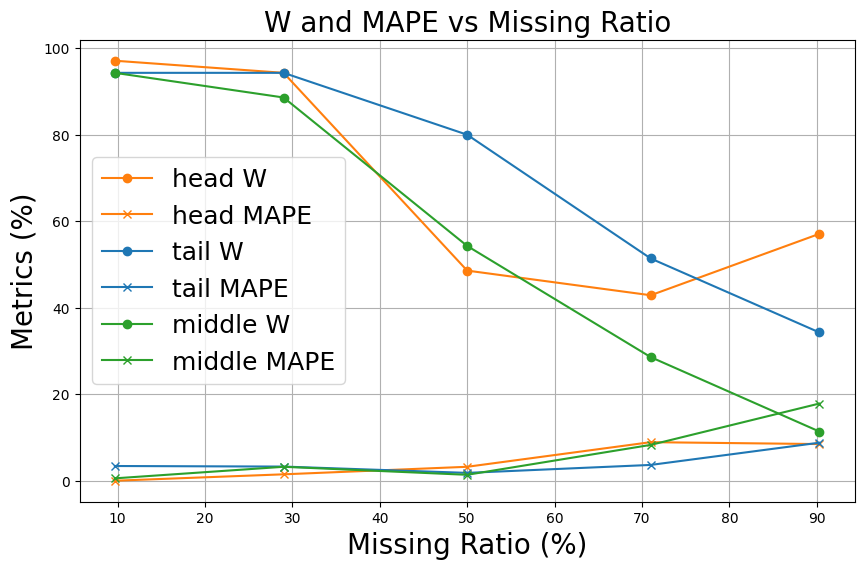

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Data preparation based on the table provided
data = {
    "欠損割合": [9.7, 29.0, 50.0, 71.0, 90.3],
    "head_W": [97.1, 94.3, 48.6, 42.9, 57.1],
    "head_MAPE": [0.04, 1.52, 3.26, 8.95, 8.51],
    "tail_W": [94.3, 94.3, 80.0, 51.4, 34.3],
    "tail_MAPE": [3.44, 3.31, 1.85, 3.69, 8.83],
    "middle_W": [94.3, 88.6, 54.3, 28.6, 11.4],
    "middle_MAPE": [0.59, 3.26, 1.41, 8.32, 17.88],
}

# Creating the DataFrame
df = pd.DataFrame(data)

# Plotting the data with different colors and markers
plt.figure(figsize=(10, 6))

# Head - Same color (Orange), different markers (circle for W, cross for MAPE)
plt.plot(df["欠損割合"], df["head_W"], label="head W", marker="o", color="tab:orange")
plt.plot(df["欠損割合"], df["head_MAPE"], label="head MAPE", marker="x", color="tab:orange")

# Tail - Same color (Blue), different markers (circle for W, cross for MAPE)
plt.plot(df["欠損割合"], df["tail_W"], label="tail W", marker="o", color="tab:blue")
plt.plot(df["欠損割合"], df["tail_MAPE"], label="tail MAPE", marker="x", color="tab:blue")

# Middle - Same color (Green), different markers (circle for W, cross for MAPE)
plt.plot(df["欠損割合"], df["middle_W"], label="middle W", marker="o", color="tab:green")
plt.plot(df["欠損割合"], df["middle_MAPE"], label="middle MAPE", marker="x", color="tab:green")

# Adding titles and labels in English
plt.title("W and MAPE vs Missing Ratio", fontsize=20)
plt.xlabel("Missing Ratio (%)", fontsize=20)
plt.ylabel("Metrics (%)", fontsize=20)
plt.legend(fontsize=18)

# Display the plot
plt.grid(True)
plt.show()